# Cat and Dog Classification
Classify images of cats and dogs using Histogram of Oriented Gradients (HOG) for feature extraction and Decision Tree for classification. 

In [45]:
import os
import numpy as np
from skimage.io import imread,imsave
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [38]:
# Load dataset
data_dir = './dataset'
images, labels = [], []

for file in os.listdir(data_dir):
    if file.endswith('.jpg'):
        img_path = os.path.join(data_dir, file)
 
        if file.startswith('cat'):
            labels.append(0)  # Cat
        elif file.startswith('dog'):
            labels.append(1)  # Dog
        else:
            continue

        img = imread(img_path)
        img = rgb2gray(img)  # Convert to grayscale
        img_resized = resize(img, (128, 128), anti_aliasing=True)
        images.append(img_resized)

images = np.array(images)
labels = np.array(labels)
print('Images shape:', images.shape)
print('Labels shape:', labels.shape)
print(f'Number of cats: {np.sum(labels == 0)}')
print(f'Number of dogs: {np.sum(labels == 1)}')

Images shape: (615, 128, 128)
Labels shape: (615,)
Number of cats: 260
Number of dogs: 355


In [39]:
def extract_hog_features(images, visualize=False):
    """Extract HOG features from a list of grayscale images.
    
    Args:
        images: Array of grayscale images (N, 128, 128).
        visualize: If True, return HOG visualizations.
    
    Returns:
        hog_features: Array of HOG features (N, feature_size).
        hog_images: Array of HOG visualizations (N, 128, 128) if visualize=True, else None.
    """
    feature_size = hog(images[0]).shape[0]
    n = len(images)
    hog_features = np.zeros(shape=(n,feature_size))
    hog_images = None
    if visualize:
        hog_images = np.zeros(shape=(n,128,128))
    for i,img in enumerate(images):
        features, hog_image = hog(img,visualize=True,feature_vector=True)
        if visualize:
            hog_images[i] = hog_image
        hog_features[i] = features
        
    return hog_features,hog_images

In [40]:
def split_and_save_dataset(images, labels, test_size=0.2, train_dir='./dog-cat/train', test_dir='./dog-cat/test'):
    """Split dataset into training and test sets and save images to separate directories.
    
    Args:
        images: Array of grayscale images (N, 128, 128).
        labels: Array of labels (0 for cat, 1 for dog).
        test_size: Fraction of data for test set.
        train_dir: Directory to save training images.
        test_dir: Directory to save test images.
    
    Returns:
        X_train, X_test: HOG features for training and test sets.
        y_train, y_test: Labels for training and test sets.
        idx_train, idx_test: Indices for training and test sets.
    """
    features, _ = extract_hog_features(images, visualize=False)
    indices = np.arange(features.shape[0])
    df = np.column_stack((features, labels, indices))
    df_train, df_test = train_test_split(df, test_size=test_size)
    X_train = df_train[:, :-2]
    X_test = df_test[:, :-2]
    y_train = df_train[:, -2].astype(int)
    y_test = df_test[:, -2].astype(int)

    idx_train = df_train[:, -1].astype(int)
    idx_test = df_test[:, -1].astype(int)
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    
    for j, i in enumerate(idx_train):
        label_name = 'cat' if y_train[j] == 0 else 'dog'
        save_img = (images[i] * 255).astype(np.uint8)
        imsave(os.path.join(train_dir, f'{i}_{label_name}.jpg'), save_img)

    for j, i in enumerate(idx_test):
        label_name = 'cat' if y_test[j] == 0 else 'dog'
        save_img = (images[i] * 255).astype(np.uint8)
        imsave(os.path.join(test_dir, f'{i}_{label_name}.jpg'), save_img)

    return X_train, X_test, y_train, y_test, idx_train, idx_test

In [ ]:
def train_random_forest(X_train, y_train):
    """Train a Decision Tree classifier on HOG features.
    
    Args:
        X_train: HOG features for training (N_train, feature_size).
        y_train: Training labels (0 for cat, 1 for dog).
    
    Returns:
        clf: Trained Random Forest classifier.
    """
    # param_grid = {
    #     'n_estimators': [200, 300],
    #     'max_depth': [10, 20],
    #     'min_samples_split': [2, 5]
    # }
    # grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
    # grid_search.fit(X_train, y_train)
    # best_params = grid_search.best_params_
    # clf = RandomForestClassifier(**best_params)
    # clf.fit(X_train, y_train)
    # return clf
    clf = RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=2)
    clf.fit(X_train, y_train)
    return clf

In [42]:
def evaluate_model(clf, X_test, y_test):
    """Evaluate the Decision Tree classifier on the test set.
    
    Args:
        clf: Trained Decision Tree classifier.
        X_test: HOG features for test set (N_test, feature_size).
        y_test: Test labels (0 for cat, 1 for dog).
    
    Returns:
        accuracy: Test set accuracy.
        y_pred: Predicted labels for test set.
    """
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy, y_pred

Test Accuracy: 0.9756


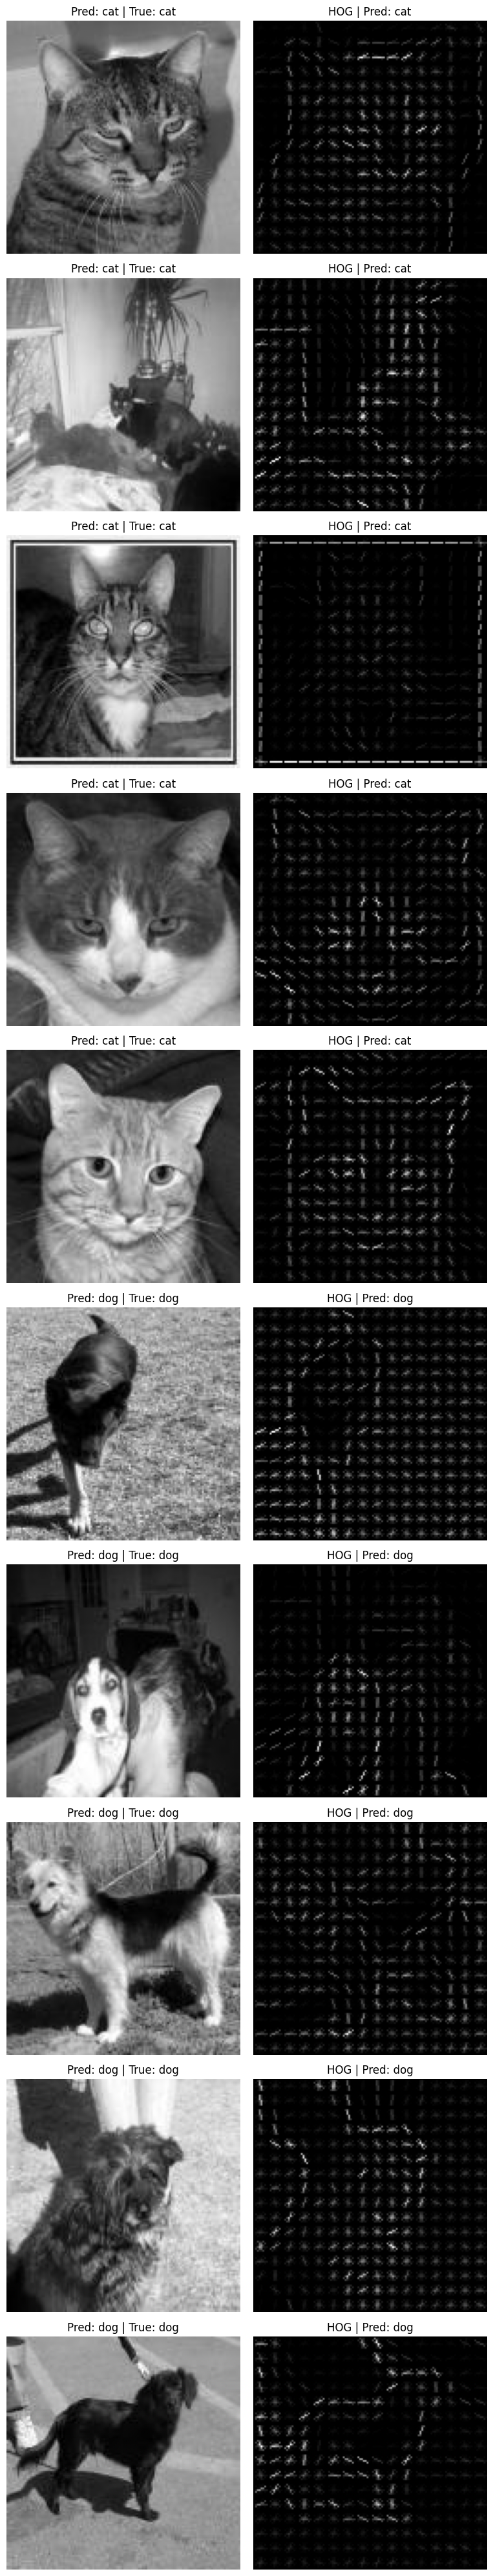

In [43]:
# Extract HOG features
hog_features, hog_images = extract_hog_features(images, visualize=True)

# Split and save dataset
X_train, X_test, y_train, y_test, idx_train, idx_test = split_and_save_dataset(images, labels, test_size=0.2)

# Train Decision Tree
clf = train_random_forest(X_train, y_train)

# Evaluate model
accuracy, y_pred = evaluate_model(clf, X_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')

# Visualize results
classes = ['cat', 'dog']
cat_indices = [idx for idx in idx_test if y_test[np.where(idx_test == idx)[0][0]] == 0]
dog_indices = [idx for idx in idx_test if y_test[np.where(idx_test == idx)[0][0]] == 1]
sample_indices = cat_indices[:min(5, len(cat_indices))] + dog_indices[:min(5, len(dog_indices))]

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(8, 4 * len(sample_indices)))
for i, idx in enumerate(sample_indices):
    ax = axes[i, 0] if len(sample_indices) > 1 else axes[0]
    true_label = y_test[np.where(idx_test == idx)[0][0]]
    pred_label = y_pred[np.where(idx_test == idx)[0][0]]
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f'Pred: {classes[pred_label]} | True: {classes[true_label]}')
    ax.axis('off')

    ax = axes[i, 1] if len(sample_indices) > 1 else axes[1]
    ax.imshow(hog_images[idx], cmap='gray')
    ax.set_title(f'HOG | Pred: {classes[pred_label]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [48]:
clf = SVC(C=10, kernel='rbf', gamma='scale')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc

0.9349593495934959